In [25]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Step 1: Load Data
train_data = np.load('train.npz')
valid_data = np.load('val.npz')
test_data = np.load('test.npz')

# Assuming the datasets contain features and labels in separate arrays
X_train = train_data['x']  # Features from train.npz
y_train = train_data['y']  # Labels from train.npz

X_valid = valid_data['x']  # Features from valid.npz
y_valid = valid_data['y']  # Actual labels for validation

X_test = test_data['X']  # Features from test.npz
y_test = test_data['y']  # Actual labels for test

# Step 2: Train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

print("--- Training Random Forest ---")
# Train the model on the full training set
rf_model.fit(X_train, y_train)

# Step 3: Evaluate on the Validation Set
y_pred_valid = rf_model.predict(X_valid)

# Calculate R² score on validation data
r2_valid = r2_score(y_valid, y_pred_valid)

# Step 4: Evaluate on the Test Set
y_pred_test = rf_model.predict(X_test)

# Calculate MAE, RMSE, and R² score for the test set
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

# Step 5: Output Results in the Requested Format
print(f"--- Training Random Forest ---")
print(f"Training R^2 Score: {rf_model.score(X_train, y_train):.4f}")
print(f"Validation R^2 Score: {r2_valid:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test R^2 Score: {r2_test:.4f}")

# Optionally, save the model for later use
joblib.dump(rf_model, 'random_forest_model.pkl')


Data preprocessing complete.
--- Training Random Forest ---
--- Training Random Forest ---
Training R^2 Score: 0.9779
Validation R^2 Score: 0.9085
Test MAE: 1.8026
Test RMSE: 4.9955
Test R^2 Score: 0.9196


['random_forest_model.pkl']

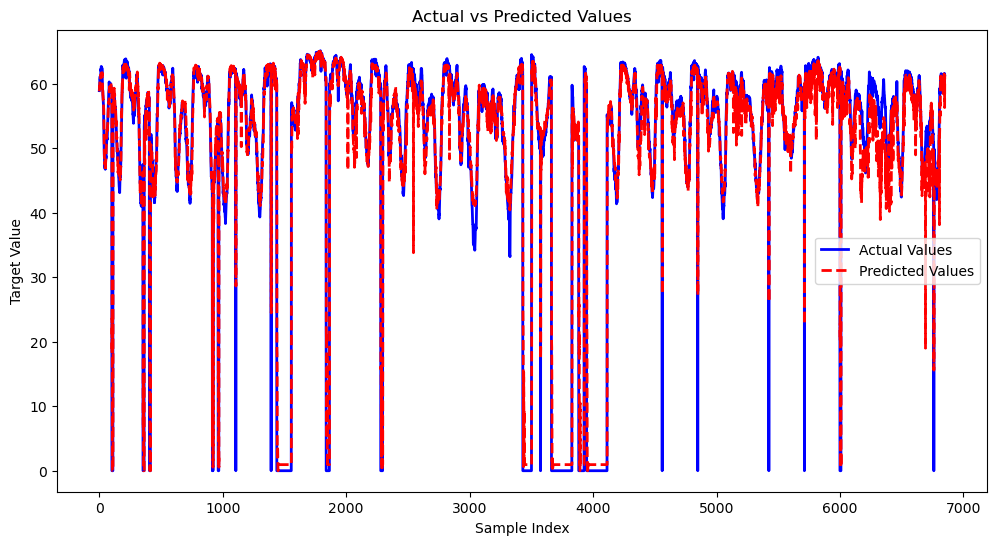

Test R^2 Score: 0.9196


In [48]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Load preprocessed data
data = np.load("processed_data.npz")
X_test, y_test = data['X_test'], data['y_test']

# Load trained Random Forest model
from joblib import load
rf = load("random_forest_model.joblib")

# Make predictions
y_pred = rf.predict(X_test)

# Plot Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Values', color='blue', linewidth=2)
plt.plot(y_pred, label='Predicted Values', color='red', linestyle='dashed', linewidth=2)
plt.title("Actual vs Predicted Values")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.show()

# Optional: Print R^2 Score for Reference
r2 = r2_score(y_test, y_pred)
print(f"Test R^2 Score: {r2:.4f}")


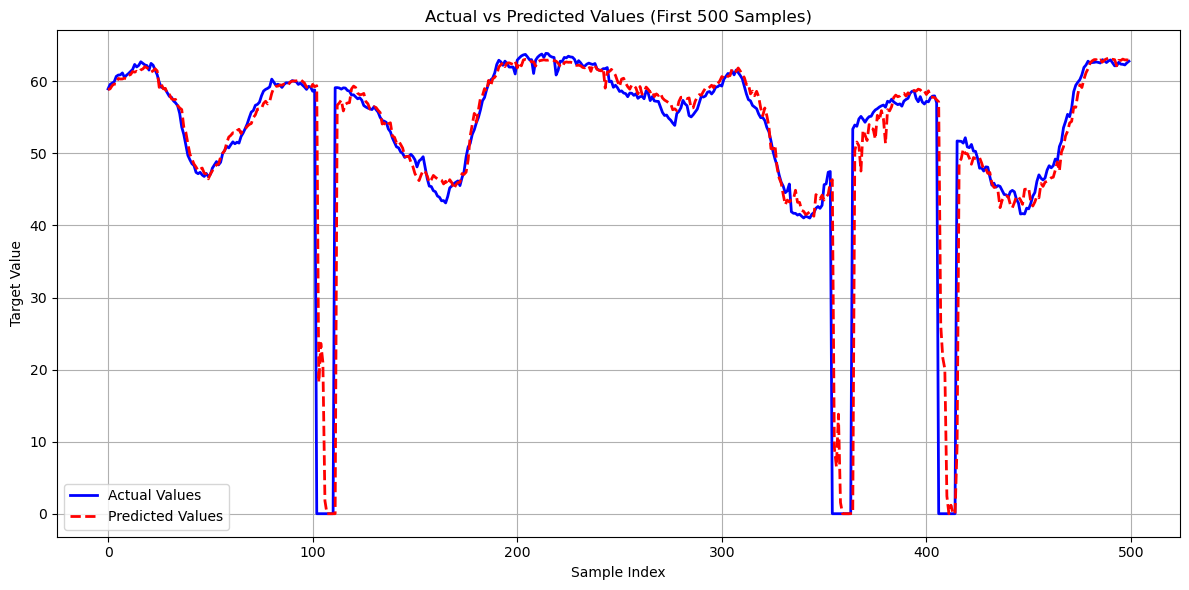

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

data = np.load("processed_data.npz")
X_test, y_test = data['X_test'], data['y_test']

from joblib import load
rf = load("random_forest_model.joblib")

# Make predictions
y_pred = rf.predict(X_test)

# Ensure the test target values are in 1D if needed
if len(y_test.shape) > 1:
    y_test = y_test.flatten()

# Plot Actual vs Predicted Values for the first 500 samples
plt.figure(figsize=(12, 6))
plt.plot(y_test[:500], label='Actual Values', color='blue', linewidth=2)
plt.plot(y_pred[:500], label='Predicted Values', color='red', linestyle='dashed', linewidth=2)
plt.title("Actual vs Predicted Values (First 500 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



R^2 Score (Test Data): 0.9196


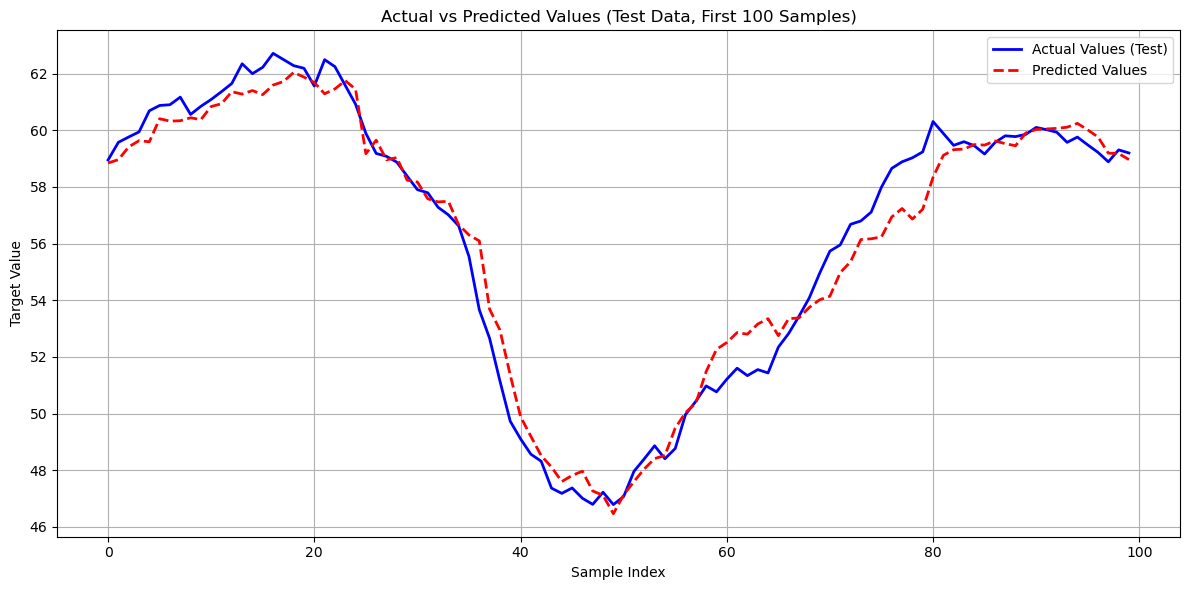

R^2 Score (Validation Data): -1.0038


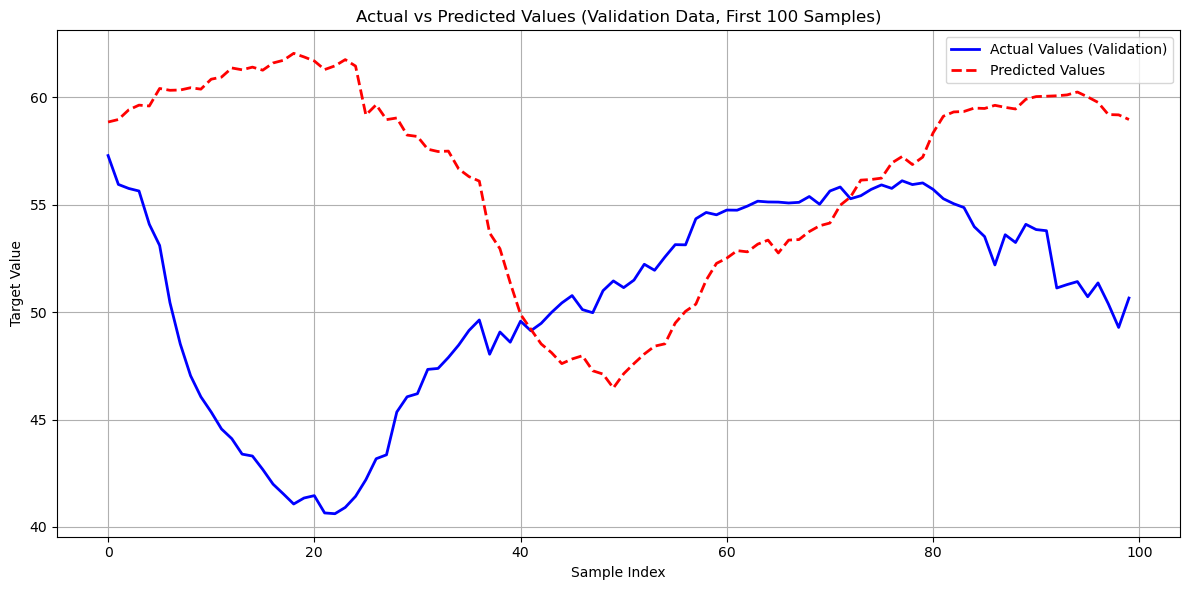

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from joblib import load

# Load preprocessed test data
test_data = np.load("processed_data.npz")
X_test, y_test = test_data['X_test'], test_data['y_test']

# Load validation data
val_data = np.load("val.npz")

# Preprocess validation data
def preprocess(data):
    X = data['x'].reshape((data['x'].shape[0], -1))  # Flatten input
    y = data['y'][:, 0, :, 0].mean(axis=1)  # Average across features
    return X, y

X_val, y_val = preprocess(val_data)

# Load trained Random Forest model
rf = load("random_forest_model.joblib")

# Predict on test data
X_test_flat = X_test.reshape((X_test.shape[0], -1))  # Flatten test data
y_pred = rf.predict(X_test_flat)

# Ensure the test target values are in 1D if needed
if len(y_test.shape) > 1:
    y_test = y_test.flatten()

# Option 1: Compare predictions with test ground truth
y_test = y_test[:len(y_pred)]  # Ensure consistency in size
r2_test = r2_score(y_test, y_pred)
print(f"R^2 Score (Test Data): {r2_test:.4f}")

# Plot for the first 100 samples (Test Data)
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Actual Values (Test)', color='blue', linewidth=2)
plt.plot(y_pred[:100], label='Predicted Values', color='red', linestyle='dashed', linewidth=2)
plt.title("Actual vs Predicted Values (Test Data, First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Option 2: Compare predictions with validation ground truth
min_length = min(len(y_val), len(y_pred))  # Align lengths
y_val = y_val[:min_length]
y_pred_trimmed = y_pred[:min_length]

r2_val = r2_score(y_val, y_pred_trimmed)
print(f"R^2 Score (Validation Data): {r2_val:.4f}")

# Plot for the first 100 samples (Validation Data)
plt.figure(figsize=(12, 6))
plt.plot(y_val[:100], label='Actual Values (Validation)', color='blue', linewidth=2)
plt.plot(y_pred_trimmed[:100], label='Predicted Values', color='red', linestyle='dashed', linewidth=2)
plt.title("Actual vs Predicted Values (Validation Data, First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


R^2 Score (Test Data): 0.9196


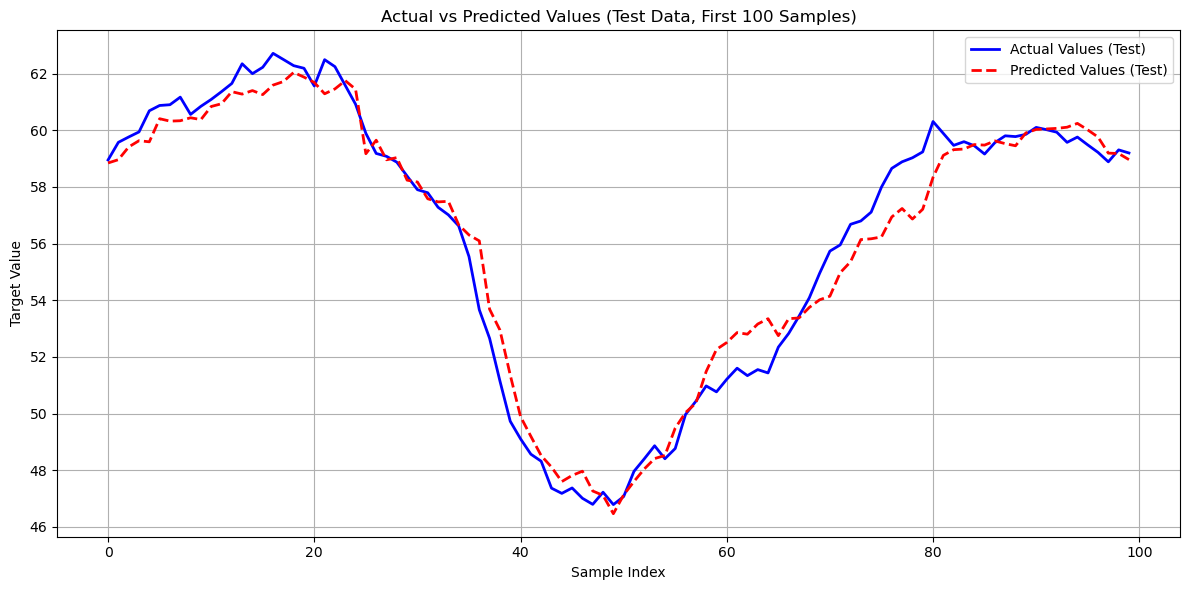

R^2 Score (Validation Data): -11.0889


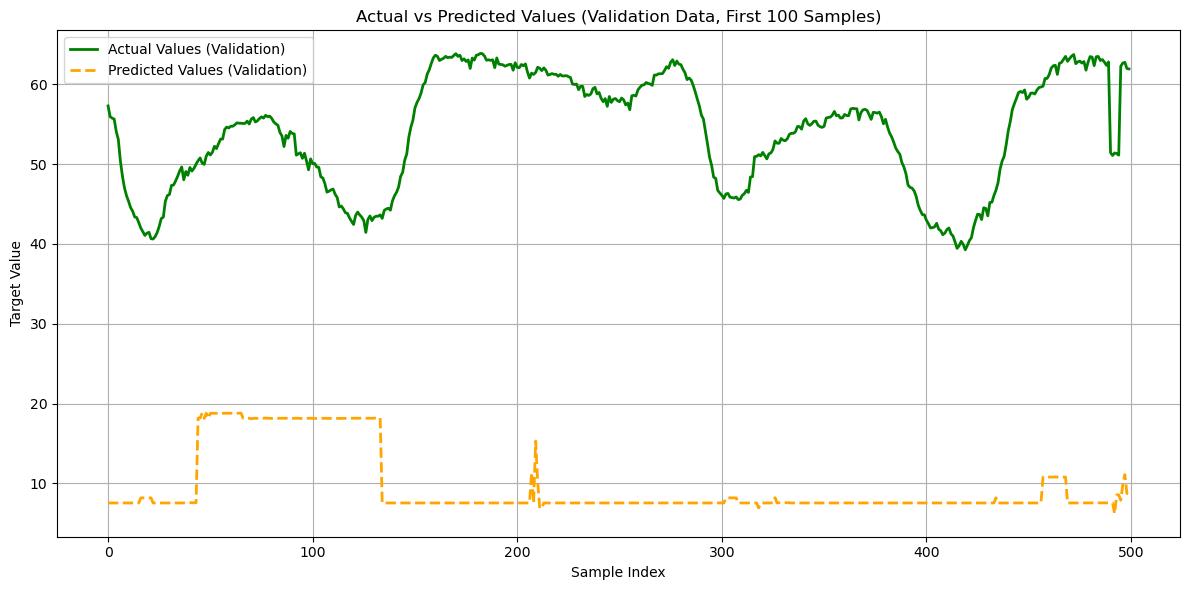

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from joblib import load

# Load preprocessed test data
test_data = np.load("processed_data.npz")
X_test, y_test = test_data['X_test'], test_data['y_test']

# Load validation data
val_data = np.load("val.npz")

# Preprocess validation data
def preprocess(data):
    X = data['x'].reshape((data['x'].shape[0], -1))  # Flatten input
    y = data['y'][:, 0, :, 0].mean(axis=1)  # Average across features
    return X, y

X_val, y_val = preprocess(val_data)

# Load trained Random Forest model
rf = load("random_forest_model.joblib")

# Predict on test data
X_test_flat = X_test.reshape((X_test.shape[0], -1))  # Flatten test data
y_pred_test = rf.predict(X_test_flat)

# Predict on validation data
y_pred_val = rf.predict(X_val)

# Ensure the test target values are in 1D if needed
if len(y_test.shape) > 1:
    y_test = y_test.flatten()

# ---- TEST DATA ----
# Align lengths
y_test = y_test[:len(y_pred_test)]  
r2_test = r2_score(y_test, y_pred_test)
print(f"R^2 Score (Test Data): {r2_test:.4f}")

# Plot for the first 100 samples (Test Data)
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Actual Values (Test)', color='blue', linewidth=2)
plt.plot(y_pred_test[:100], label='Predicted Values (Test)', color='red', linestyle='dashed', linewidth=2)
plt.title("Actual vs Predicted Values (Test Data, First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- VALIDATION DATA ----
# Align lengths for validation data
min_length_val = min(len(y_val), len(y_pred_val))
y_val = y_val[:min_length_val]
y_pred_val_trimmed = y_pred_val[:min_length_val]

r2_val = r2_score(y_val, y_pred_val_trimmed)
print(f"R^2 Score (Validation Data): {r2_val:.4f}")

# Plot for the first 100 samples (Validation Data)
plt.figure(figsize=(12, 6))
plt.plot(y_val[:500], label='Actual Values (Validation)', color='green', linewidth=2)
plt.plot(y_pred_val_trimmed[:500], label='Predicted Values (Validation)', color='orange', linestyle='dashed', linewidth=2)
plt.title("Actual vs Predicted Values (Validation Data, First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
